In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
# select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [5]:
# architecture
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 8, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3),
            nn.Sigmoid(),
            nn.Flatten()
        )
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (8, 3, 3)),
            nn.ConvTranspose2d(8, 8, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 8, kernel_size=3),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        # apply encoder
        features = self.encoder(x)
        # apply decoder
        return self.decoder(features)
    def __str__(self):
        return str(self.encoder)+str(self.decoder)

In [6]:
autoencoder = Autoencoder()

In [8]:
!wget http://agentspace.org/download/pytorch_mnist_autoencoder_model.pth
model_name = 'pytorch_mnist_autoencoder_model.pth'
#from google.colab import files
#print('upload',model_name)
#files.upload()
autoencoder.load_state_dict(torch.load(model_name, map_location=device))

--2025-11-04 07:27:24--  http://agentspace.org/download/pytorch_mnist_autoencoder_model.pth
Resolving agentspace.org (agentspace.org)... 62.168.101.9
Connecting to agentspace.org (agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/pytorch_mnist_autoencoder_model.pth [following]
--2025-11-04 07:27:25--  https://www.agentspace.org/download/pytorch_mnist_autoencoder_model.pth
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 52651 (51K)
Saving to: ‘pytorch_mnist_autoencoder_model.pth.1’

pytorch_mnist_autoe 100%[===================>]  51.42K   160KB/s    in 0.3s    

2025-11-04 07:27:26 (160 KB/s) - ‘pytorch_mnist_autoencoder_model.pth.1’ saved [52651/52651]



<All keys matched successfully>

In [12]:
class Classifier(nn.Module):
    def __init__(self, encoder, num_features, num_classes, num_hidden=512):
        super().__init__()
        self.encoder = encoder
        self.perceptron = nn.Sequential(
            nn.Linear(num_features,num_hidden),
            nn.ReLU(),
            nn.Linear(num_hidden,num_classes),
        )
    def forward(self, x):
        features = self.encoder(x)
        logits = self.perceptron(features)
        if self.training:
            return logits
        else:
            return F.softmax(logits, dim=1)

In [10]:
# make encoder non-trainable
print(f"number of trainable parameters: {sum(p.numel() for p in autoencoder.encoder.parameters() if p.requires_grad)}")

for param in autoencoder.encoder.parameters():
    param.requires_grad = False

print(f"number of trainable parameters: {sum(p.numel() for p in autoencoder.encoder.parameters() if p.requires_grad)}")

In [17]:
# create classifier
model = Classifier(autoencoder.encoder,72,10).to(device)

In [25]:
# create train and test dataloader
batch_size = 512
train_loader = DataLoader(datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor()), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor()), batch_size=batch_size, shuffle=False)

In [15]:
# Define loss funcion
criterion = nn.CrossEntropyLoss()

In [18]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
# scheduler
step_size = 16
gamma = 0.7
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

In [22]:
# training
history_loss = []
history_acc = []
history_test_acc = []
epoch = 0

In [23]:
def train(num_epochs):
    global epoch
    for _ in range(num_epochs):
        # change model in training mood
        model.train()

        # to record loss and accuracy
        batch_loss = []
        total_train = 0
        correct_train = 0

        for batch, (x_train, y_train) in enumerate(train_loader):

            # send data to device
            input = x_train.to(device)

            # reset parameters gradient to zero
            optimizer.zero_grad()

            # forward pass to the model
            output = model(input)

            # categorization
            expected_output = y_train.to(device)

            # cross entropy loss
            loss = criterion(output, expected_output)

            # find gradients
            loss.backward()
            # update parameters using gradients
            optimizer.step()

            # recording loss
            batch_loss.append(loss.item())

            # recording accuracy
            total_train += output.shape[0]
            correct_train += torch.argmax(output,dim=1).to('cpu').eq(y_train).sum().item()

        epoch_loss = np.average(batch_loss)
        epoch_acc = (100.0 * correct_train) / total_train

        history_loss.append(epoch_loss)
        history_acc.append(epoch_acc)

        total_test = 0
        correct_test = 0

        model.eval()

        for batch, (x_test, y_test) in enumerate(test_loader):

            # send data to device
            input = x_test.to(device)

            # forward pass to the model
            with torch.no_grad():
                output = model(input)

            # recording accuracy
            total_test += output.shape[0]
            correct_test += torch.argmax(output,dim=1).to('cpu').eq(y_test).sum().item()

        test_acc = (100.0 * correct_test) / total_test

        history_test_acc.append(test_acc)

        print(f'Epoch: {epoch} Loss: {epoch_loss:.6f} Accuracy: {epoch_acc:.4f} Test accuracy: {test_acc:.4f} Learning Rate: {scheduler.get_last_lr()[0]:.7f}')
        scheduler.step()
        epoch += 1

In [26]:
# training
num_epochs = 40
print(f"number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(72*512+512+10*512+10)
train(num_epochs)

Epoch: 0 Loss: 0.806871 Accuracy: 81.2133 Test accuracy: 83.6900 Learning Rate: 0.0010000
Epoch: 1 Loss: 0.565245 Accuracy: 85.4517 Test accuracy: 86.2000 Learning Rate: 0.0010000
Epoch: 2 Loss: 0.468022 Accuracy: 87.5500 Test accuracy: 87.4100 Learning Rate: 0.0010000
Epoch: 3 Loss: 0.415240 Accuracy: 88.6800 Test accuracy: 87.9900 Learning Rate: 0.0010000
Epoch: 4 Loss: 0.381727 Accuracy: 89.2917 Test accuracy: 88.7200 Learning Rate: 0.0010000
Epoch: 5 Loss: 0.358444 Accuracy: 89.8067 Test accuracy: 89.5500 Learning Rate: 0.0010000
Epoch: 6 Loss: 0.341151 Accuracy: 90.1333 Test accuracy: 90.1000 Learning Rate: 0.0010000
Epoch: 7 Loss: 0.327653 Accuracy: 90.4233 Test accuracy: 90.4800 Learning Rate: 0.0010000
Epoch: 8 Loss: 0.316640 Accuracy: 90.6817 Test accuracy: 90.9600 Learning Rate: 0.0010000
Epoch: 9 Loss: 0.307361 Accuracy: 90.8917 Test accuracy: 91.2600 Learning Rate: 0.0010000


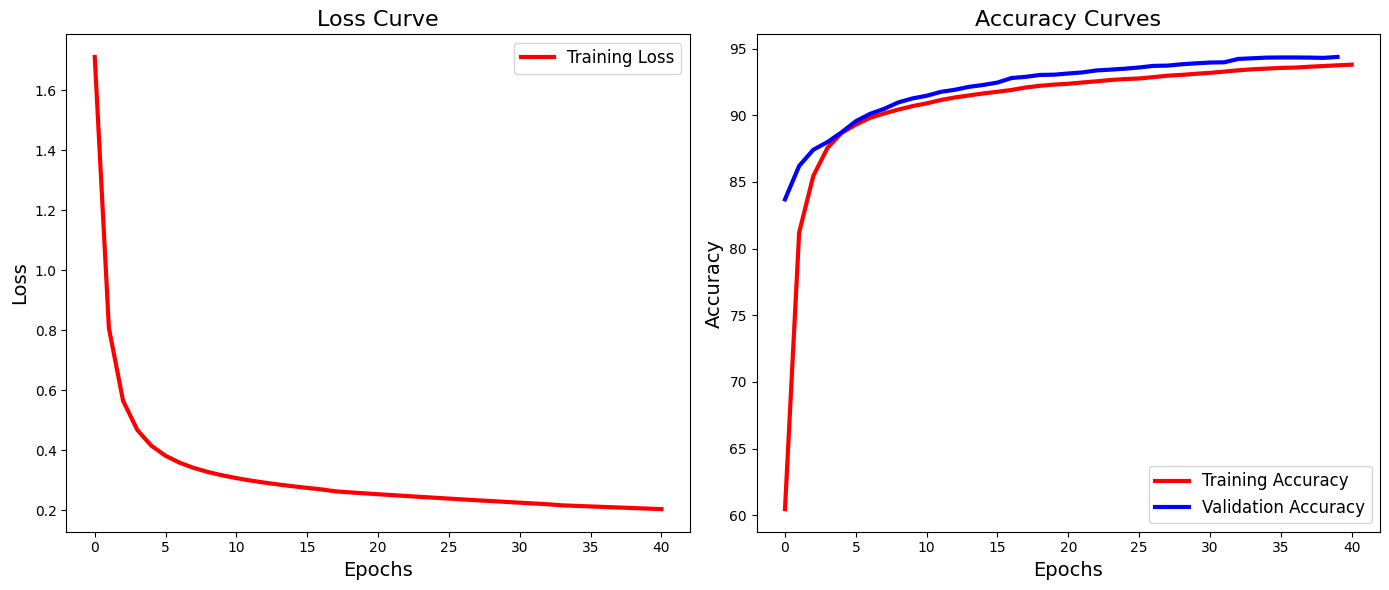

In [32]:
def plot_history():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
    # Loss curve
    axes[0].plot(history_loss, 'r', linewidth=3.0)
    axes[0].set_title('Loss Curve', fontsize=16)
    axes[0].set_xlabel('Epochs', fontsize=14)
    axes[0].set_ylabel('Loss', fontsize=14)
    axes[0].legend(['Training Loss'], fontsize=12)
    # Accuracy curves
    axes[1].plot(history_acc, 'r', linewidth=3.0)
    axes[1].plot(history_test_acc, 'b', linewidth=3.0)
    axes[1].set_title('Accuracy Curves', fontsize=16)
    axes[1].set_xlabel('Epochs', fontsize=14)
    axes[1].set_ylabel('Accuracy', fontsize=14)
    axes[1].legend(['Training Accuracy', 'Validation Accuracy'], fontsize=12)
    plt.tight_layout()
    plt.show()

plot_history()


In [37]:
# make encoder trainable
for param in model.encoder.parameters():
    param.requires_grad = True

In [38]:
# fine tunning
history_loss = []
history_acc = []
history_test_acc = []
epoch = 0
print(f"number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

number of trainable parameters: 47898


In [40]:
# fine tunning
num_epochs = 40
train(num_epochs)

Epoch: 0 Loss: 0.182808 Accuracy: 94.4300 Test accuracy: 95.1800 Learning Rate: 0.0004900
Epoch: 1 Loss: 0.155036 Accuracy: 95.3017 Test accuracy: 95.7200 Learning Rate: 0.0004900
Epoch: 2 Loss: 0.136992 Accuracy: 95.7867 Test accuracy: 96.1400 Learning Rate: 0.0004900
Epoch: 3 Loss: 0.123396 Accuracy: 96.2333 Test accuracy: 96.5800 Learning Rate: 0.0004900
Epoch: 4 Loss: 0.113023 Accuracy: 96.5550 Test accuracy: 96.8500 Learning Rate: 0.0004900
Epoch: 5 Loss: 0.104444 Accuracy: 96.8100 Test accuracy: 97.0400 Learning Rate: 0.0004900
Epoch: 6 Loss: 0.098122 Accuracy: 96.9867 Test accuracy: 97.1300 Learning Rate: 0.0004900
Epoch: 7 Loss: 0.092869 Accuracy: 97.1717 Test accuracy: 97.1800 Learning Rate: 0.0004900
Epoch: 8 Loss: 0.085605 Accuracy: 97.3933 Test accuracy: 97.3700 Learning Rate: 0.0003430
Epoch: 9 Loss: 0.081903 Accuracy: 97.5483 Test accuracy: 97.4300 Learning Rate: 0.0003430


In [45]:
train(10)

Epoch: 30 Loss: 0.047080 Accuracy: 98.5833 Test accuracy: 98.4100 Learning Rate: 0.0002401
Epoch: 31 Loss: 0.046369 Accuracy: 98.6033 Test accuracy: 98.4500 Learning Rate: 0.0002401
Epoch: 32 Loss: 0.045744 Accuracy: 98.6200 Test accuracy: 98.4500 Learning Rate: 0.0002401
Epoch: 33 Loss: 0.045054 Accuracy: 98.6400 Test accuracy: 98.4600 Learning Rate: 0.0002401
Epoch: 34 Loss: 0.044351 Accuracy: 98.6667 Test accuracy: 98.5100 Learning Rate: 0.0002401
Epoch: 35 Loss: 0.043697 Accuracy: 98.6950 Test accuracy: 98.5200 Learning Rate: 0.0002401
Epoch: 36 Loss: 0.043008 Accuracy: 98.7083 Test accuracy: 98.5200 Learning Rate: 0.0002401
Epoch: 37 Loss: 0.042332 Accuracy: 98.7267 Test accuracy: 98.4900 Learning Rate: 0.0002401
Epoch: 38 Loss: 0.041714 Accuracy: 98.7450 Test accuracy: 98.5100 Learning Rate: 0.0002401
Epoch: 39 Loss: 0.041108 Accuracy: 98.7650 Test accuracy: 98.5400 Learning Rate: 0.0002401


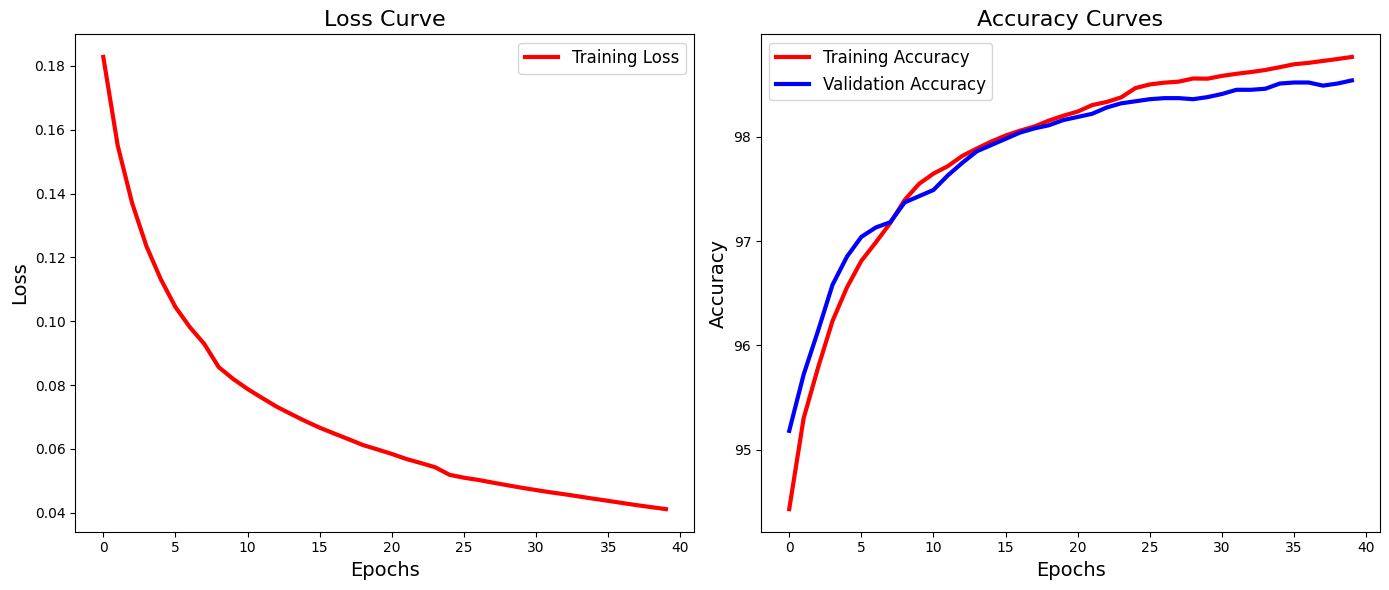

In [49]:
plot_history()

In [46]:
# Save model and weights
def save():
    torch.save(model.state_dict(), classifier_name) # weights only
    print('Saved trained model at %s ' % classifier_name)

In [47]:
classifier_name = 'mnist_classifier.pth'
save()

Saved trained model at mnist_classifier.pth 


In [48]:
# download model
from google.colab import files
files.download(classifier_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>